# Task 1 – Data Profiling & Data Quality

The evidence behind the data-quality issues of `leads.csv` and `conversions.csv`. The issues themselves, with their
criticality and handling, are in the [README](../README.md#task-1--data-profiling--data-quality).

The notebook assumes no formats up front. Each section looks at the data, states a **Finding** and, where needed,
applies a **Fix** to a working copy, so every later section builds on cleaner data.

In [1]:
import warnings

import numpy as np
import pandas as pd
import plotly.express as px
from pandas.tseries.api import guess_datetime_format

# Shared by the notebooks, see notebooks/common/
from common import RAW_DATA_DIR, configure_plotly

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
configure_plotly()

## 1. Load the raw files

Everything is read as text, so the notebook sees exactly what is in the files.

In [2]:
leads_raw = pd.read_csv(RAW_DATA_DIR / "leads.csv", dtype=str, keep_default_na=False)
conv_raw = pd.read_csv(RAW_DATA_DIR / "conversions.csv", dtype=str, keep_default_na=False)

pd.DataFrame(
    {
        "rows": [len(leads_raw), len(conv_raw)],
        "columns": [leads_raw.shape[1], conv_raw.shape[1]],
    },
    index=["leads", "conversions"],
)

,rows,columns
leads,123,6
conversions,51,6


In [3]:
display(leads_raw.head(3))
conv_raw.head(3)

,lead_id,email,vertical,source,created_at,region
0,1087,Sophia.wagner@aon.at,haushalt,direct,05/02/2024,
1,1056,lea.brunner@outlook.com,haushalt,newsletter,2024-04-22,Kaernten
2,1071,michael.fischer@gmx.at,auto,google,25.09.2024,Vorarlberg


,conversion_id,lead_id,email,premium,signed_date,status
0,5036,1103,sophie.gruber@gmx.at,422.42,15.03.2024,active
1,5021,1047,julia.brunner@hotmail.com,"1299,57",04.03.2024,active
2,5001,1076,julia.pichler@hotmail.com,"431,77",30.04.2024,active


## 2. What formats do the values have?

Each value is reduced to its **shape**: digits become `9`, runs of capitals `A`, runs of lower-case letters `a`
and spaces `␣`. So `2024-04-22` becomes `9999-99-99`, and `  Lea.Weber@gmx.at` becomes `␣␣Aa.a@a.a`. Counting the
shapes per column shows the format variants without knowing what to look for.

In [4]:
def shape(s: pd.Series) -> pd.Series:
    """Reduce every value to its format: digits -> 9, letter runs -> A / a, spaces -> ␣."""
    return (
        s.str.replace(r"\d", "9", regex=True)
        .str.replace(r"[A-Z]+", "A", regex=True)
        .str.replace(r"[a-z]+", "a", regex=True)
        .str.replace(" ", "␣", regex=False)
        .replace("", "(empty)")
    )


def shape_profile(df: pd.DataFrame, table: str) -> pd.DataFrame:
    """One row per (column, shape) with the number of rows and one example value."""
    values = df.melt(var_name="column", value_name="value")
    values["shape"] = shape(values["value"])
    return (
        values.groupby(["column", "shape"], as_index=False)
        .agg(rows=("value", "size"), example=("value", "first"))
        .assign(table=table)
    )


shapes = pd.concat([shape_profile(leads_raw, "leads"), shape_profile(conv_raw, "conversions")])

# Columns with a single shape are consistent. Only the ones that mix shapes are shown, as a styled
# table, so that all rows appear at once instead of in pages.
n_shapes = shapes.groupby(["table", "column"])["shape"].transform("nunique")
(
    shapes[n_shapes > 1]
    .sort_values(["table", "column", "rows"], ascending=[False, True, False])
    .set_index(["table", "column", "shape"])
    .style
)

**Finding:** without a single expected pattern, the shapes reveal most of the problems:

| column | what the shapes show |
|---|---|
| `created_at`, `signed_date` | three date formats: `9999-99-99`, `99.99.9999` and `99/99/9999` |
| `email` (both files) | leading and trailing spaces (`␣␣a.a@a.a`, `a.a@a.a␣`) and capitals (`A.A@A.A`, `Aa.a@a.a`) |
| `premium` | decimal point *and* decimal comma (`999.99` vs `999,99`), negative values (`-99.99`), empty values |
| `conversions.lead_id` | 4-digit *and* 5-digit ids (`99999`), plus empty values |
| `status` | one value in capitals (`A`) |
| `vertical`, `region` | empty values |

`lead_id` in the leads, `conversion_id` and `source` each have a single, clean shape.

## 3. Fix 1: whitespace, empty strings and id types

In the working copies, all text is trimmed and empty strings are missing values. The ids become nullable integers
(`Int64`), so that a missing id does not turn the column into floats (`1087.0`).

In [5]:
def trim_and_null(df: pd.DataFrame) -> pd.DataFrame:
    """Strip surrounding whitespace from every text column and turn empty strings into NaN."""
    df = df.copy()
    for col in df.select_dtypes(str):
        df[col] = df[col].str.strip()
    return df.replace("", np.nan)


leads = trim_and_null(leads_raw).astype({"lead_id": "Int64"})
conv = trim_and_null(conv_raw).astype({"conversion_id": "Int64", "lead_id": "Int64"})

pd.concat({"leads": leads.dtypes, "conversions": conv.dtypes}).rename("dtype").to_frame()

dtype
leads       lead_id        Int64
            email            str
            vertical         str
            source           str
            created_at       str
            region           str
conversions conversion_id  Int64
            lead_id        Int64
            email            str
            premium          str
            signed_date      str
            status           str

## 4. Missing values

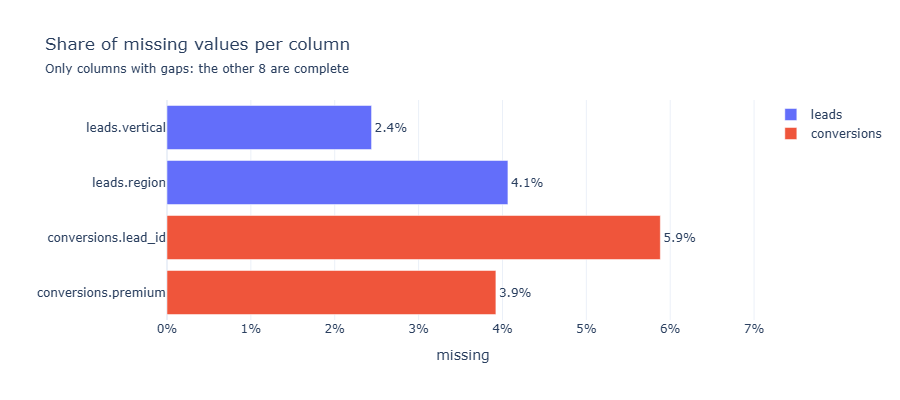

In [6]:
missing = (
    pd.concat({"leads": leads.isna().mean(), "conversions": conv.isna().mean()})
    .rename_axis(["table", "column"])
    .rename("missing_share")
    .reset_index()
)
missing["column"] = missing["table"] + "." + missing["column"]
gaps = missing[missing["missing_share"] > 0]

fig = px.bar(
    gaps,
    x="missing_share",
    y="column",
    color="table",
    orientation="h",
    text_auto=".1%",
    title="Share of missing values per column",
    labels={"missing_share": "missing", "column": "", "table": ""},
)
complete = len(missing) - len(gaps)
fig.update_layout(title_subtitle_text=f"Only columns with gaps: the other {complete} are complete")
fig.update_traces(textposition="outside")
fig.update_xaxes(tickformat=".0%", range=[0, gaps["missing_share"].max() * 1.2])
fig.update_yaxes(autorange="reversed")
fig.show()

**Finding:** four columns have gaps, each in a few rows:
- leads: `vertical` 3 times (2.4 %), `region` 5 times (4.1 %).
- conversions: `lead_id` 3 times (5.9 %), so these contracts cannot be linked to a lead (section 9); `premium`
  2 times (3.9 %, section 7).

## 5. Value sets of the categorical columns

Every column with at most 20 distinct values counts as categorical:

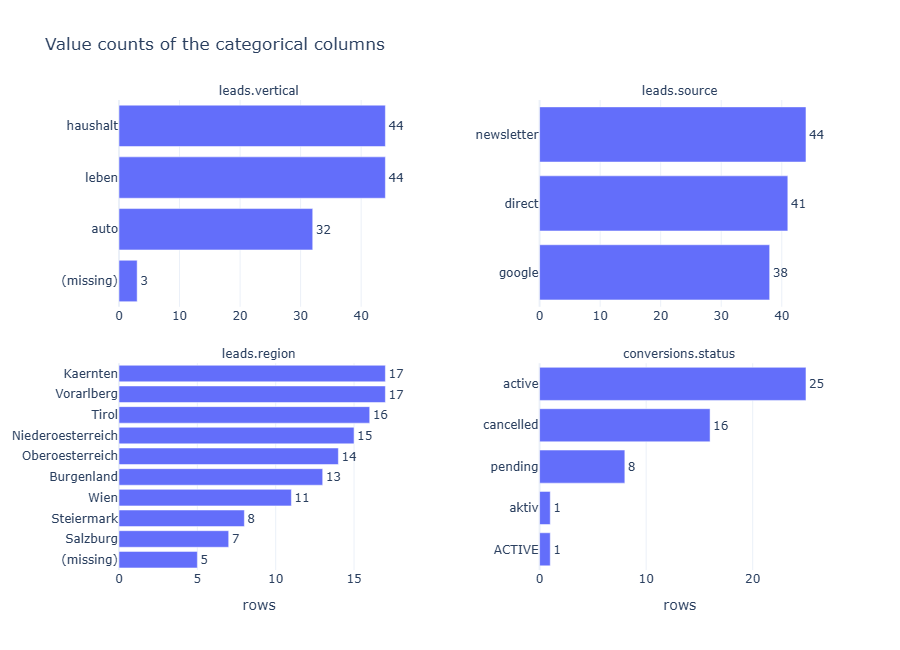

In [7]:
MAX_CATEGORIES = 20


def value_counts_long(df: pd.DataFrame, table: str) -> pd.DataFrame:
    """Value counts (missing values included) of all low-cardinality columns, in long format."""
    columns = [col for col in df.columns if df[col].nunique() <= MAX_CATEGORIES]
    counts = (
        df[columns]
        .fillna("(missing)")
        .melt(var_name="column", value_name="value")
        .value_counts()
        .rename("rows")
        .reset_index()
    )
    counts["column"] = table + "." + counts["column"]
    return counts


counts = pd.concat([value_counts_long(leads, "leads"), value_counts_long(conv, "conversions")])

fig = px.bar(
    counts,
    x="rows",
    y="value",
    orientation="h",
    text_auto=True,
    facet_col="column",
    facet_col_wrap=2,
    facet_row_spacing=0.12,
    facet_col_spacing=0.2,
    title="Value counts of the categorical columns",
    height=650,
)
fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_xaxes(matches=None, showticklabels=True)
fig.update_yaxes(matches=None, showticklabels=True, title=None, autorange="reversed")
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

**Finding:**
- `status` has **5** values instead of the documented 3: `ACTIVE` and `aktiv` appear next to `active`. Anything
  that counts active contracts would miss them.
- `vertical` and `source` only hold the documented values; `region` holds the 9 Austrian federal states.

### E-mail addresses

The e-mail address is the only attribute that identifies a person across both files. How many different addresses
are left after each cleaning step?

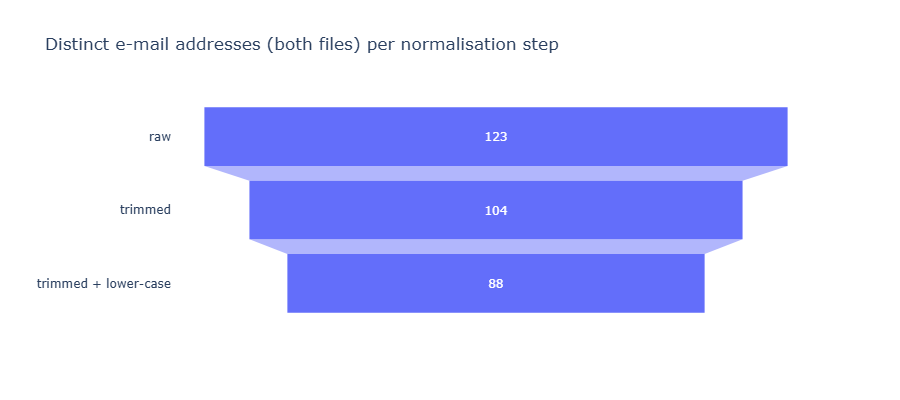

In [8]:
emails = pd.concat([leads_raw["email"], conv_raw["email"]])
email_steps = pd.DataFrame(
    {
        "step": ["raw", "trimmed", "trimmed + lower-case"],
        "distinct addresses": [
            emails.nunique(),
            emails.str.strip().nunique(),
            emails.str.strip().str.lower().nunique(),
        ],
    }
)

fig = px.funnel(
    email_steps,
    x="distinct addresses",
    y="step",
    title="Distinct e-mail addresses (both files) per normalisation step",
    labels={"step": ""},
)
fig.show()

**Finding:** 123 spellings shrink to 104 after trimming and to 88 addresses after lower-casing.

**Fix 2:** lower-case the e-mails and the status, and map `aktiv` to `active`.

In [9]:
leads["email"] = leads["email"].str.lower()
conv["email"] = conv["email"].str.lower()
conv["status"] = conv["status"].str.lower().replace({"aktiv": "active"})

conv["status"].value_counts()

status
active       27
cancelled    16
pending       8
Name: count, dtype: int64

## 6. Dates: discover the formats, then parse

### 6.1 What do the standard approaches do?

In [10]:
created = leads["created_at"]
naive = pd.to_datetime(created, errors="coerce")
mixed = pd.to_datetime(created, format="mixed")

pd.DataFrame(
    {
        "parsed": [naive.notna().sum(), mixed.notna().sum()],
        "failed (NaT)": [naive.isna().sum(), mixed.isna().sum()],
    },
    index=["to_datetime(errors='coerce')", "to_datetime(format='mixed')"],
)

,parsed,failed (NaT)
to_datetime(errors='coerce'),26,97
to_datetime(format='mixed'),123,0


- The default takes the format of the first value (`05/02/2024`) for all values: 97 of 123 dates fail.
- `format="mixed"` guesses a format per value and parses everything without an error. Whether the result is right
  is checked in 6.3.

### 6.2 Discover the formats

pandas' `guess_datetime_format` runs twice per distinct value, once month-first and once day-first. If the two
guesses differ, the value is **ambiguous**: `03/05/2024` could be 5 March or 3 May.

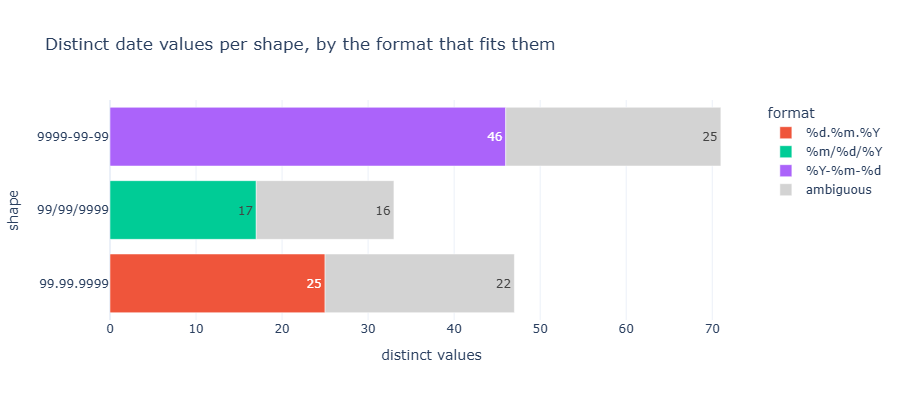

In [11]:
def guess_format(value: str, dayfirst: bool) -> str | None:
    """pandas' format guesser, without the warning it emits when dayfirst does not fit."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        return guess_datetime_format(value, dayfirst=dayfirst)


date_values = (
    pd.concat([leads["created_at"], conv["signed_date"]], ignore_index=True)
    .dropna()
    .drop_duplicates()
)
formats = pd.DataFrame(
    {
        "shape": shape(date_values),
        "month_first": date_values.map(lambda v: guess_format(v, dayfirst=False)),
        "day_first": date_values.map(lambda v: guess_format(v, dayfirst=True)),
    }
)
formats["format"] = np.select(
    [formats["month_first"].isna(), formats["month_first"] == formats["day_first"]],
    ["unknown", formats["month_first"]],
    default="ambiguous",
)

evidence = (
    formats.groupby(["shape", "format"])
    .size()
    .rename("distinct values")
    .reset_index()
    .sort_values("format", key=lambda s: s.eq("ambiguous"), kind="stable")  # ambiguous last
)

fig = px.bar(
    evidence,
    x="distinct values",
    y="shape",
    color="format",
    orientation="h",
    text_auto=True,
    color_discrete_map={"ambiguous": "lightgrey"},
    title="Distinct date values per shape, by the format that fits them",
)
fig.show()

Every shape has exactly one coloured segment: all of its unambiguous values fit the same format. (The guesser is
strict: even ISO dates count as ambiguous, because year-day-month would be possible.) So each shape takes the
format of its unambiguous values:

In [12]:
format_per_shape = (
    formats[~formats["format"].isin(["ambiguous", "unknown"])]
    .groupby("shape")
    .agg(n_formats=("format", "nunique"), format=("format", "first"))
)
assert (format_per_shape["n_formats"] == 1).all(), "a shape mixes several formats"

format_per_shape = format_per_shape["format"]
format_per_shape

shape
99.99.9999    %d.%m.%Y
99/99/9999    %m/%d/%Y
9999-99-99    %Y-%m-%d
Name: format, dtype: str

**Finding:** three formats, one per shape:
- `9999-99-99` is ISO (`%Y-%m-%d`),
- `99.99.9999` is day-first (`%d.%m.%Y`),
- `99/99/9999` is **month-first** (`%m/%d/%Y`): all 17 unambiguous slash dates have the month first.

The ambiguous values are parsed with the format of their shape. That is an assumption; Task 2 checks it against
the days from lead to signing.

### 6.3 Parse by shape and compare

In [13]:
def parse_dates(s: pd.Series, format_per_shape: pd.Series) -> pd.Series:
    """Parse each value with the format of its shape. Values of an unknown shape become NaT."""
    shapes = shape(s)
    parts = [
        pd.to_datetime(s[shapes == value_shape], format=fmt, errors="coerce")
        for value_shape, fmt in format_per_shape.items()
    ]
    return pd.concat(parts).reindex(s.index)


parsed = parse_dates(created, format_per_shape)
wrong = parsed != mixed

print(
    f"parse failures: {(created.notna() & parsed.isna()).sum()}, "
    f"dates that format='mixed' put on a different day: {wrong.sum()}"
)
pd.DataFrame({"text": created, "format='mixed'": mixed, "by shape": parsed})[wrong].head()

parse failures: 0, dates that format='mixed' put on a different day: 14


,text,format='mixed',by shape
4,06.10.2024,2024-06-10,2024-10-06
8,11.08.2024,2024-11-08,2024-08-11
12,01.08.2024,2024-01-08,2024-08-01
15,09.02.2024,2024-09-02,2024-02-09
29,08.05.2024,2024-08-05,2024-05-08


**Finding:** parsing by shape leaves no failures. `format="mixed"` raised no error either, but put 14 of the 123
lead dates on the **wrong day**: it reads `06.10.2024` as 10 June instead of 6 October. A silent error like this
is worse than a loud one.

**Fix 3:** parse both date columns by shape.

In [14]:
for df, col in [(leads, "created_at"), (conv, "signed_date")]:
    text = df[col]
    df[col] = parse_dates(text, format_per_shape)
    print(
        f"{col}: {(text.notna() & df[col].isna()).sum()} parse failures, "
        f"from {df[col].min():%Y-%m-%d} to {df[col].max():%Y-%m-%d}"
    )

created_at: 0 parse failures, from 2024-01-05 to 2024-10-31
signed_date: 0 parse failures, from 2024-01-16 to 2024-11-29


### 6.4 Leads and conversions over time

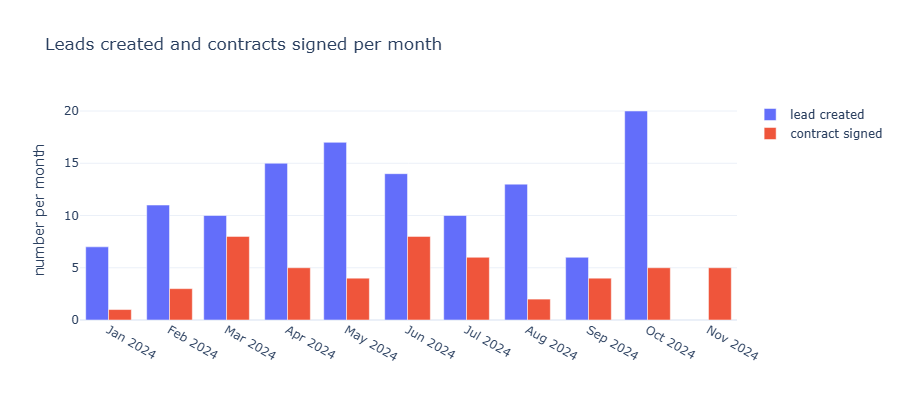

In [15]:
events = pd.concat(
    [
        pd.DataFrame({"date": leads["created_at"], "event": "lead created"}),
        pd.DataFrame({"date": conv["signed_date"], "event": "contract signed"}),
    ],
    ignore_index=True,
)

# Aggregate first, then plot: the figure only carries the monthly counts.
monthly = (
    events.assign(month=events["date"].dt.to_period("M").dt.start_time)
    .groupby(["month", "event"])
    .size()
    .rename("count")
    .reset_index()
)

fig = px.bar(
    monthly,
    x="month",
    y="count",
    color="event",
    barmode="group",
    category_orders={"event": ["lead created", "contract signed"]},
    title="Leads created and contracts signed per month",
    labels={"count": "number per month", "event": ""},
)
fig.update_xaxes(dtick="M1", tickformat="%b %Y", title=None)
fig.show()

**Finding:** leads run from 2024-01-05 to 2024-10-31, contracts from 2024-01-16 to 2024-11-29. A contract is
signed some time after its lead, so the leads of the last weeks can still convert, and the conversion rates of the
latest months look too low (right-censoring).

## 7. Premium: parsing and value range

What does a naive conversion do with the decimal commas?

In [16]:
naive = pd.to_numeric(conv["premium"], errors="coerce")
lost = conv["premium"].notna() & naive.isna()

print(
    f"naive to_numeric: {lost.sum()} of {conv['premium'].notna().sum()} "
    f"non-missing premiums silently became NaN"
)
conv.loc[lost, ["conversion_id", "premium"]].head()

naive to_numeric: 13 of 49 non-missing premiums silently became NaN


,conversion_id,premium
1,5021,"1299,57"
2,5001,"431,77"
3,5030,"212,26"
8,5028,"1102,21"
11,5043,"894,41"


**Fix 4:** replace the decimal comma with a point before casting to a nullable float (`Float64`).

In [17]:
premium_text = conv["premium"]
conv["premium"] = pd.to_numeric(
    premium_text.str.replace(",", ".", regex=False),
    errors="coerce",
).astype("Float64")

failed = premium_text.notna() & conv["premium"].isna()
print(f"parse failures after replacing the decimal comma: {failed.sum()}")
conv["premium"].describe()

parse failures after replacing the decimal comma: 0


count          49.0
mean     597.104898
std      399.500814
min         -217.61
25%          260.71
50%          570.49
75%          881.65
max         1359.55
Name: premium, dtype: Float64

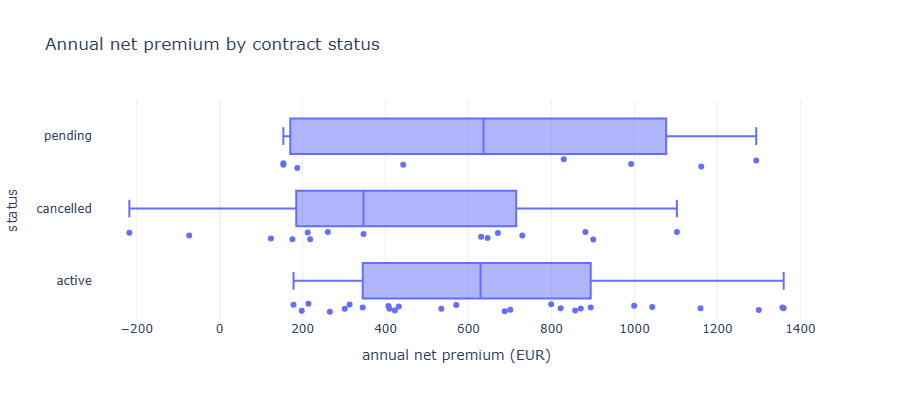

,conversion_id,lead_id,status
23,5024,1104,active
39,5033,1059,cancelled


In [18]:
fig = px.box(
    conv,
    x="premium",
    y="status",
    points="all",
    hover_data=["conversion_id"],
    title="Annual net premium by contract status",
    labels={"premium": "annual net premium (EUR)"},
)
fig.show()

conv.loc[conv["premium"].isna(), ["conversion_id", "lead_id", "status"]]

**Finding:**
- 13 of 49 premiums (27 %) use a decimal comma, and a naive conversion silently turns them into `NaN`. No
  thousands separators occur, so replacing the comma is safe. (The counts still include the duplicate row found
  in section 8; it has a decimal point.)
- The values range from −217.61 to 1,359.55 EUR. The 2 negative premiums both belong to cancelled contracts.
- 2 premiums are missing, one of them on an **active** contract, so any total of active premiums lacks that
  contract.

## 8. Duplicates

With every column parsed, two rows are duplicates when their values match, however the files spell them
(`1299,57` and `1299.57`).

In [19]:
for name, df, key in [("leads", leads, "lead_id"), ("conversions", conv, "conversion_id")]:
    exact = df.duplicated(keep=False)
    key_dup = df.duplicated(subset=[key], keep=False)
    print(
        f"{name}: exact duplicate rows = {df.duplicated().sum()} "
        f"(rows involved: {exact.sum()}), duplicate {key} values = {df[key][key_dup].nunique()}"
    )

leads: exact duplicate rows = 0 (rows involved: 0), duplicate lead_id values = 4
conversions: exact duplicate rows = 1 (rows involved: 2), duplicate conversion_id values = 1


In [20]:
dup_leads = leads[leads.duplicated("lead_id", keep=False)].sort_values("lead_id")
dup_leads.head(10)

,lead_id,email,vertical,source,created_at,region
55,1019,sophie.eder@gmail.com,haushalt,direct,2024-08-18,Niederoesterreich
86,1019,sophie.eder@gmail.com,haushalt,direct,2024-08-18,Wien
90,1030,sophie.aigner@hotmail.com,haushalt,newsletter,2024-01-24,Salzburg
115,1030,sophie.aigner@hotmail.com,haushalt,newsletter,2024-01-24,Tirol
18,1075,sophia.weber@aon.at,NaN,newsletter,2024-05-12,Tirol
75,1075,sophia.weber@aon.at,leben,google,2024-05-12,Burgenland
10,1117,noah.gruber@gmail.com,haushalt,newsletter,2024-08-19,Tirol
17,1117,noah.gruber@gmail.com,haushalt,google,2024-08-19,Wien


In how many of the duplicated leads does each column disagree between the copies?

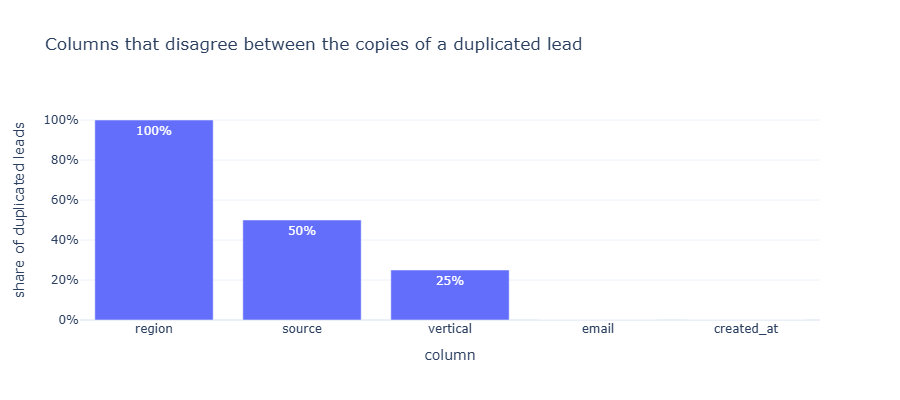

In [21]:
differs = (
    dup_leads.groupby("lead_id")
    .nunique(dropna=False)
    .gt(1)
    .mean()
    .sort_values(ascending=False)
    .rename("share of duplicated leads")
    .rename_axis("column")
    .reset_index()
)

fig = px.bar(
    differs,
    x="column",
    y="share of duplicated leads",
    text_auto=".0%",
    title="Columns that disagree between the copies of a duplicated lead",
)
fig.update_yaxes(tickformat=".0%", range=[0, 1.1])
fig.show()

**Finding:**
- **conversions:** one exact duplicate row (`conversion_id` 5020). It would count a contract and its premium
  twice.
- **leads:** no exact duplicates, but 4 `lead_id`s occur twice **with different content**. `region` differs in
  all 4, `source` in 2, `vertical` in 1; `email` and `created_at` never differ.

A lead that was submitted or exported twice would give identical copies. A column that differs *every time* looks
like a **fan-out from an upstream join**, e.g. a region looked up per session. If so, `region` is not a reliable
attribute of a lead.

**Fix 5:** drop the exact duplicate conversion. The checks below only need the `email` and `created_at` of a lead,
which never differ between its copies.

In [22]:
conv = conv.drop_duplicates()
leads_unique = leads.drop_duplicates("lead_id")

print(f"conversions: {len(conv)} rows, leads_unique: {len(leads_unique)} rows")

conversions: 50 rows, leads_unique: 119 rows


### The same person with several leads

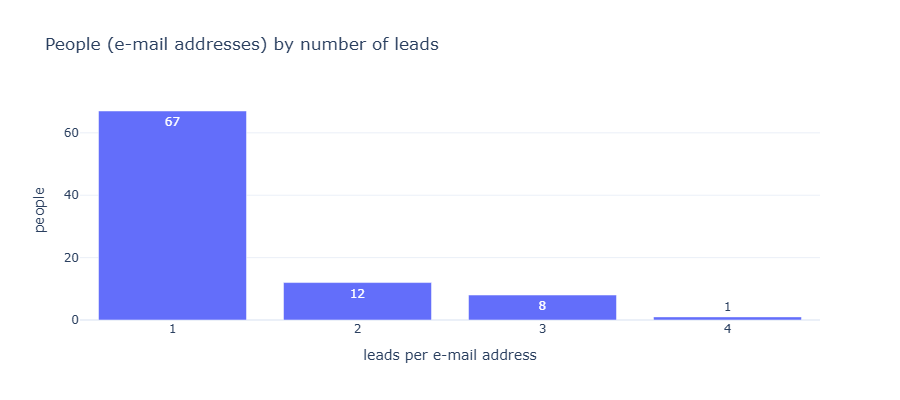

In [23]:
people = (
    leads_unique.groupby("email")["lead_id"]
    .nunique()
    .value_counts()
    .sort_index()
    .rename_axis("n_leads")
    .rename("people")
    .reset_index()
)

fig = px.bar(
    people,
    x="n_leads",
    y="people",
    text_auto=True,
    title="People (e-mail addresses) by number of leads",
)
fig.update_xaxes(dtick=1, title="leads per e-mail address")
fig.show()

Are there names that appear with more than one e-mail domain?

In [24]:
email_parts = (
    leads_unique["email"]
    .str.split("@", expand=True)
    .set_axis(["local", "domain"], axis=1)
)
domains_per_name = email_parts.groupby("local")["domain"].transform("nunique")

(
    leads_unique.loc[domains_per_name > 1, ["lead_id", "email", "vertical", "created_at"]]
    .sort_values("email")
)

,lead_id,email,vertical,created_at
20,1021,florian.fuchs@aon.at,haushalt,2024-03-10
25,1020,florian.fuchs@aon.at,haushalt,2024-03-21
53,1022,florian.fuchs@aon.at,haushalt,2024-05-11
91,1037,florian.fuchs@gmx.at,leben,2024-08-18
106,1046,lena.hofer@gmail.com,haushalt,2024-05-10
63,1035,lena.hofer@outlook.com,auto,2024-07-17
8,1084,lukas.mayer@aon.at,leben,2024-08-11
100,1085,lukas.mayer@aon.at,haushalt,2024-04-20
118,1033,lukas.mayer@hotmail.com,leben,2024-06-22
76,1005,paul.aigner@gmail.com,leben,2024-08-24


**Finding:** 21 e-mail addresses have 2–4 leads. That is no error (people compare more than once), but it makes
"lead" and "customer" different grains. 5 names appear with two e-mail domains, e.g. `paul.aigner@gmail.com` and
`paul.aigner@hotmail.com`. They could be the same person, but the data cannot prove it.

## 9. How do the conversions relate to the leads?

The conversions carry no vertical and no channel: both come from the lead, so the link decides to which channel,
vertical and month a conversion is attributed.

### 9.1 Does every conversion point to an existing lead?

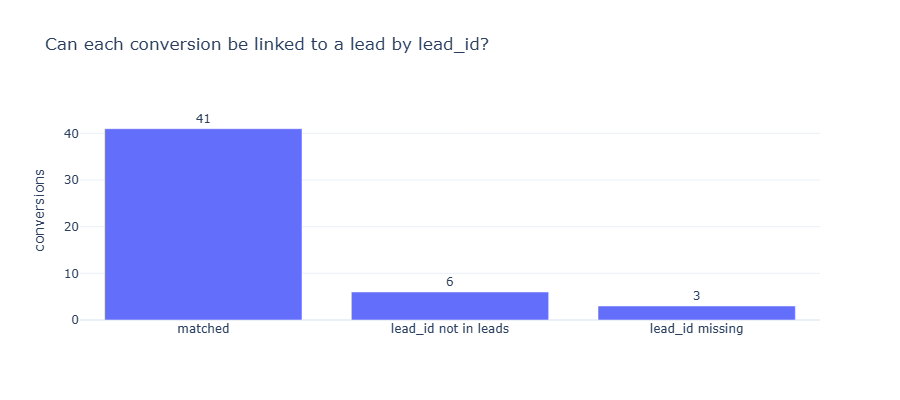

In [25]:
conv["link"] = np.select(
    [conv["lead_id"].isna(), conv["lead_id"].isin(leads_unique["lead_id"])],
    ["lead_id missing", "matched"],
    default="lead_id not in leads",
)

fig = px.bar(
    conv["link"].value_counts().rename("conversions").reset_index(),
    x="link",
    y="conversions",
    text_auto=True,
    title="Can each conversion be linked to a lead by lead_id?",
)
fig.update_traces(textposition="outside")
fig.update_xaxes(title=None)
fig.update_yaxes(range=[0, conv["link"].value_counts().max() * 1.15])
fig.show()

In [26]:
# The range of the lead ids: in the leads, and in the conversions by how they link
lead_ids = pd.concat(
    [
        pd.DataFrame({"lead_id": leads_unique["lead_id"], "ids": "leads"}),
        pd.DataFrame({"lead_id": conv["lead_id"], "ids": "conversions, " + conv["link"]}),
    ],
    ignore_index=True,
).dropna()
lead_ids.groupby("ids")["lead_id"].agg(lead_ids="count", smallest="min", largest="max")

,lead_ids,smallest,largest
ids,,,
"conversions, lead_id not in leads",6,90672,99874
"conversions, matched",41,1003,1117
leads,119,1001,1119


**Finding:** 41 of the 50 contracts link to a lead. 3 have no `lead_id`, and 6 point to ids between 90,672 and
99,874, far outside the range of the leads (1001–1119): ids from another system rather than typos. These 9
contracts (18 %) have no vertical and no channel, and `conversions.csv` has no column to recover them from.

How often does the same `lead_id` appear in the conversions?

In [27]:
(
    conv["lead_id"]
    .value_counts()
    .value_counts()
    .rename_axis("conversions per lead_id")
    .rename("lead_ids")
)

conversions per lead_id
1    47
Name: lead_ids, dtype: Int64

**Finding:** a contract names one lead, and a lead is named by one contract at most.

### 9.2 Do a contract and its lead belong to the same person?

Each lead gets the vertical its copies agree on (section 8).

In [28]:
vertical_per_lead = leads.groupby("lead_id")["vertical"]
lead_attributes = leads_unique[["lead_id", "email", "created_at"]].assign(
    vertical=leads_unique["lead_id"].map(
        vertical_per_lead.first().where(vertical_per_lead.nunique() == 1)
    )
)

linked = conv.merge(
    lead_attributes.rename(
        columns={
            "lead_id": "linked_lead_id",
            "email": "lead_email",
            "created_at": "linked_lead_date",
        }
    ),
    left_on="lead_id",
    right_on="linked_lead_id",
)

print(
    f"conversions with a known lead: {len(linked)}, "
    f"same e-mail as their lead: {(linked['email'] == linked['lead_email']).sum()}, "
    f"with a known vertical: {linked['vertical'].notna().sum()}"
)

conversions with a known lead: 41, same e-mail as their lead: 41, with a known vertical: 40


**Finding:** every contract has the same e-mail address as the lead it names. One linked lead has no known
vertical.

### 9.3 How long before signing do a person's leads come in?

Every lead of the same person and vertical before the signing date is a candidate touchpoint of the contract. How
far back do they lie, compared with the lead the contract names? The distribution sets the attribution window,
instead of a guess.

linked leads: 40, days before signing: min 2, median 22, max 40; other leads: 7


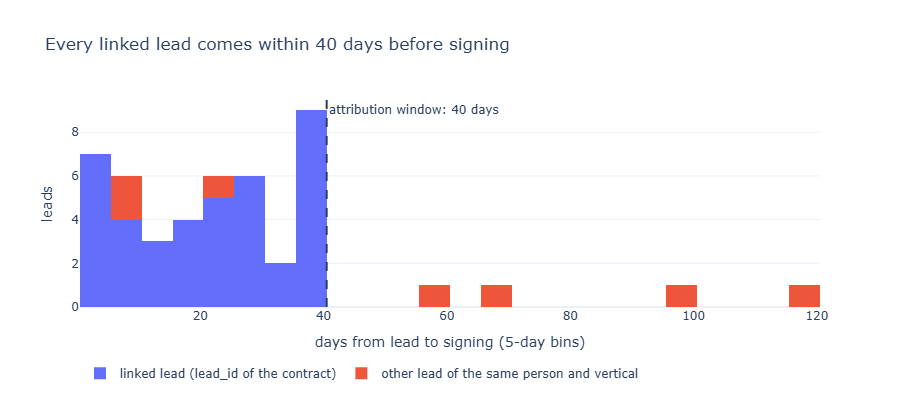

In [29]:
LINKED = "linked lead (lead_id of the contract)"
OTHER = "other lead of the same person and vertical"

journeys = (
    linked.dropna(subset=["vertical"])[
        ["conversion_id", "linked_lead_id", "linked_lead_date", "email", "vertical", "signed_date"]
    ]
    .merge(
        lead_attributes.rename(columns={"created_at": "lead_date"}),
        on=["email", "vertical"],
    )
    .query("lead_date <= signed_date")
)
journeys["days_before_signing"] = (journeys["signed_date"] - journeys["lead_date"]).dt.days
journeys["lead"] = np.where(journeys["lead_id"] == journeys["linked_lead_id"], LINKED, OTHER)

linked_days = journeys.loc[journeys["lead"] == LINKED, "days_before_signing"]
WINDOW_DAYS = int(linked_days.max())
print(
    f"linked leads: {len(linked_days)}, days before signing: min {linked_days.min()}, "
    f"median {linked_days.median():.0f}, max {WINDOW_DAYS}; "
    f"other leads: {(journeys['lead'] == OTHER).sum()}"
)

fig = px.histogram(
    journeys,
    x="days_before_signing",
    color="lead",
    category_orders={"lead": [LINKED, OTHER]},
    title=f"Every linked lead comes within {WINDOW_DAYS} days before signing",
    labels={"days_before_signing": "days from lead to signing (5-day bins)", "lead": ""},
    barmode="stack",
)
# Bins end on whole days + 0.5, so the window edge falls between two bars
fig.update_traces(xbins={"start": 0.5, "end": 120.5, "size": 5})
fig.add_vline(
    x=WINDOW_DAYS + 0.5,
    line_dash="dash",
    annotation_text=f"attribution window: {WINDOW_DAYS} days",
    annotation_position="top right",
)
fig.update_yaxes(title="leads")
fig.update_layout(legend={"orientation": "h", "y": -0.25})
fig.show()

How many leads would a shorter or a longer window take in?

In [30]:
windows = pd.DataFrame({"window_days": [14, 28, WINDOW_DAYS, 55, 56, 70, 120]})
(
    journeys.merge(windows, how="cross")
    .query("days_before_signing <= window_days")
    .groupby(["window_days", "lead"])
    .size()
    .unstack(fill_value=0)
)

lead,linked lead (lead_id of the contract),other lead of the same person and vertical
window_days,,
14,14,2
28,26,3
40,40,3
55,40,3
56,40,4
70,40,5
120,40,7


**Finding:** the linked leads lie 2 to 40 days before signing (median 22), none further back. The other leads of
the same person and vertical fall into two groups: 3 within the same weeks (8, 10 and 23 days before signing) and
4 long before (56 to 116 days), which look like separate journeys. Nothing lies between 41 and 55 days.

So the **attribution window is 40 days**, the smallest window that covers every linked lead. Any window up to 55
days takes in the same leads. That the linked leads end so sharply at 40 days may be a limit of how the source
system links leads.

### 9.4 Is the linked lead the last one before signing?

Does another lead of the same person and vertical come between the linked lead and the signing, or right after
the signing?

In [31]:
later_leads = journeys.query("lead == @OTHER and lead_date > linked_lead_date")
later_leads[
    ["conversion_id", "linked_lead_id", "linked_lead_date", "lead_id", "lead_date", "signed_date"]
]

,conversion_id,linked_lead_id,linked_lead_date,lead_id,lead_date,signed_date
3,5030,1111,2024-07-20,1110,2024-08-02,2024-08-12
17,5029,1051,2024-06-05,1053,2024-06-25,2024-07-03


In [32]:
after_signing = (
    linked.dropna(subset=["vertical"])[["conversion_id", "email", "vertical", "signed_date"]]
    .merge(
        lead_attributes.rename(columns={"created_at": "lead_date"}),
        on=["email", "vertical"],
    )
    .query("lead_date > signed_date")
)
days_to_next_lead = (
    (after_signing["lead_date"] - after_signing["signed_date"])
    .dt.days.groupby(after_signing["conversion_id"])
    .min()
)
print(
    f"contracts followed by a lead of the same person and vertical: {len(days_to_next_lead)}, "
    f"days to that lead: min {days_to_next_lead.min()}, median {days_to_next_lead.median():.0f}"
)

contracts followed by a lead of the same person and vertical: 4, days to that lead: min 24, median 46


Are there contracts of the same person and vertical that were signed within the window of each other?

In [33]:
contracts = linked.dropna(subset=["vertical"])[
    ["email", "vertical", "conversion_id", "signed_date", "status", "premium"]
]
pairs = contracts.merge(contracts, on=["email", "vertical"], suffixes=("", "_next"))
days_apart = (pairs["signed_date_next"] - pairs["signed_date"]).dt.days
pairs[(pairs["conversion_id"] != pairs["conversion_id_next"]) & days_apart.between(0, WINDOW_DAYS)]

,email,vertical,conversion_id,signed_date,status,premium,conversion_id_next,signed_date_next,status_next,premium_next
13,leon.aigner@aon.at,haushalt,5029,2024-07-03,active,344.89,5012,2024-07-31,active,1042.68


**Finding:** in 38 of the 40 contracts with a known vertical, the linked lead is the last lead before signing.
The two exceptions:
- 5030: another lead came 10 days before signing, after the linked lead.
- 5029: the lead in between (1053) is the linked lead of the same person's next haushalt contract (5012), signed
  four weeks later with another premium: a second contract rather than a duplicate.

After a signing, the next lead of the same person and vertical comes 24 days later at the earliest, so no lead is
logged twice around a signing.

So the `lead_id` names one touchpoint, mostly the last one, but not the whole customer journey.

## 10. Checks that passed

These checks found nothing:
- `lead_id` in the leads and `conversion_id` have one digit shape and no missing values.
- `source` and `region` only hold valid values (apart from gaps).
- Every `lead_id` occurs at most once in the conversions.
- Every contract has the same e-mail address as the lead it names.
- No lead is logged twice around a signing.